In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-dataset


In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv('/kaggle/input/heart-disease-dataset/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
from sklearn.model_selection import train_test_split

X,y=df.drop('target',axis=1),df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=9)

### Scale Insensitive

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest=RandomForestClassifier()
forest.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_clf=RandomForestClassifier()
nb_clf.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf=GradientBoostingClassifier()
gb_clf.fit(X_train,y_train)

GradientBoostingClassifier()

### Scale Sensitive

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.linear_model import LogisticRegression

log=KNeighborsClassifier()
log.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.svm import SVC

svc=SVC()
svc.fit(X_train_scaled,y_train)

SVC()

### Evaluation

In [ ]:
forest.score(X_test,y_test)

0.9853658536585366

In [ ]:
nb_clf.score(X_test,y_test)

0.9853658536585366

In [ ]:
gb_clf.score(X_test,y_test)

0.9707317073170731

In [ ]:
knn.score(X_test_scaled,y_test)

0.8536585365853658

In [ ]:
log.score(X_test_scaled,y_test)

0.8536585365853658

In [ ]:
svc.score(X_test_scaled,y_test)

0.9341463414634147

In [ ]:
from sklearn.metrics import recall_score

y_preds=forest.predict(X_test)
print("Forest Recall:",recall_score(y_test,y_preds))

y_preds=nb_clf.predict(X_test)
print("Naive Bayes Recall:",recall_score(y_test,y_preds))

y_preds=gb_clf.predict(X_test)
print("Gradient Boosted Recall:",recall_score(y_test,y_preds))

y_preds=knn.predict(X_test_scaled)
print("KNN Recall:",recall_score(y_test,y_preds))

y_preds=log.predict(X_test_scaled)
print("Logistic Regression Recall:",recall_score(y_test,y_preds))

y_preds=svc.predict(X_test_scaled)
print("SVM Recall:",recall_score(y_test,y_preds))

Forest Recall: 0.9859154929577465
Naive Bayes Recall: 0.9859154929577465
Gradient Boosted Recall: 0.9859154929577465
KNN Recall: 0.8732394366197183
Logistic Regression Recall: 0.8732394366197183
SVM Recall: 0.9530516431924883


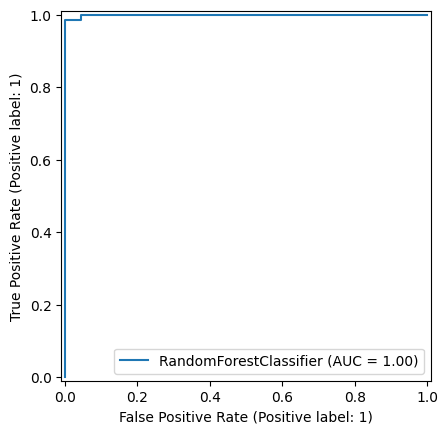

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay,roc_auc_score

RocCurveDisplay.from_estimator(forest,X_test,y_test)
plt.show()

In [ ]:
y_probs=forest.predict_proba(X_test)[:,1]
roc_auc_score(y_test,y_probs)

np.float64(0.9993565453635519)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid={
    "n_estimators":[100,200,500],
    "max_depth":[None,10,20,30],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "max_features":["sqrt","log2",None]
    }

forest=RandomForestClassifier(n_jobs=-1,random_state=9)
Grid_search=GridSearchCV(forest,param_grid,cv=3,n_jobs=-1,verbose=2)

In [ ]:
Grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 324 candidates, totalling 972 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=9),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 500]},
             verbose=2)

In [ ]:
best_forest=Grid_search.best_estimator_

In [ ]:
best_forest

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=9)

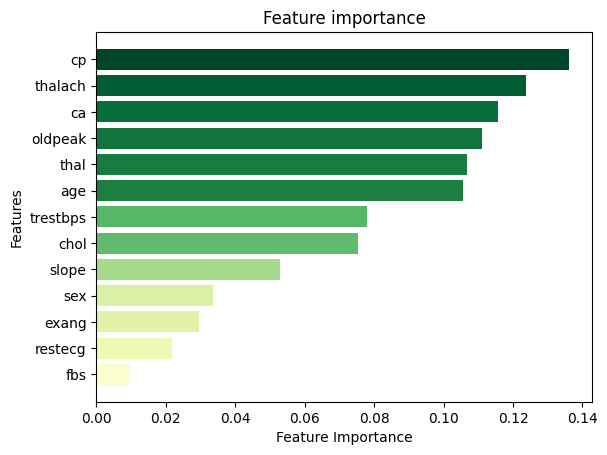

In [ ]:
import numpy as np

feature_importance=best_forest.feature_importances_
features=best_forest.feature_names_in_

sorted_idx=np.argsort(feature_importance)
sorted_features=features[sorted_idx]
sorted_importance=feature_importance[sorted_idx]

colors=plt.cm.YlGn(sorted_importance/max(sorted_importance))
plt.barh(sorted_features,sorted_importance,color=colors)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature importance")
plt.show()

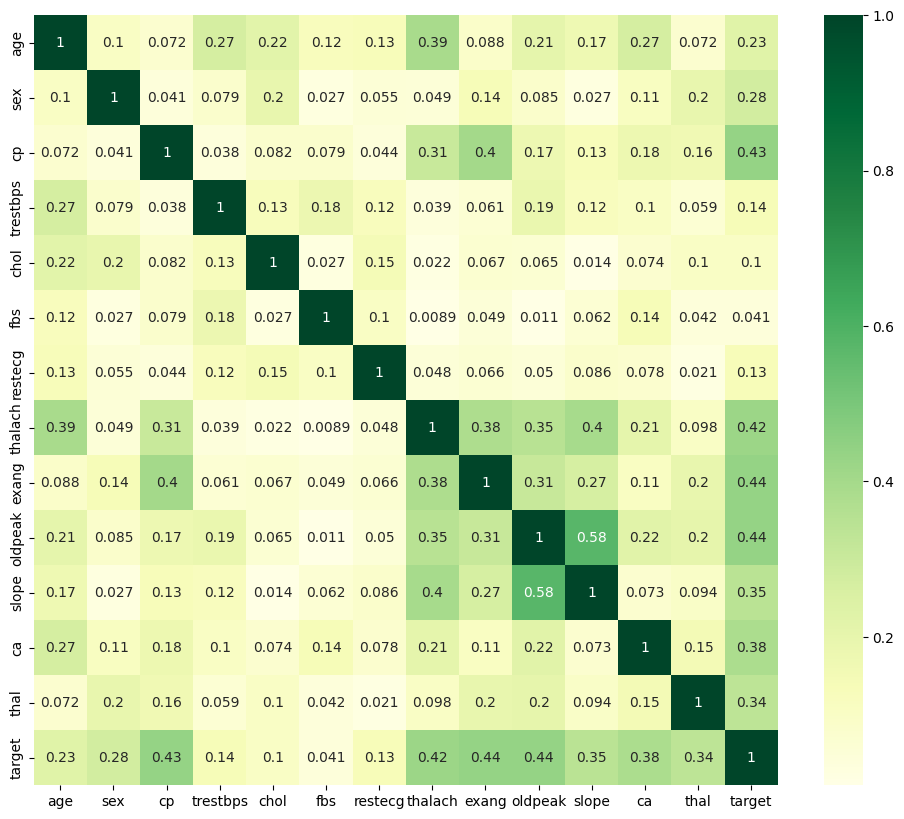

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(abs(df.corr()),annot=True,cmap='YlGn')
plt.show()